# Project 4 Machine Learning

### Streamlit application: 
https://ind320-steamlit-app1-ditto.streamlit.app/
### Github link: 
https://github.com/Ditto25/IND320-Steamlit-app1

So in this assignment I have reused my notebook from assignment 2. I started with the Elhub api to retrive hourly production data for year 2022 to 2024. Then setting up the same way I did earlier. Setting up Cassandra using Spark and then check connection to MongoDB, and later upload to MongoDB. I have to reuse the Database by adding new tables and then retrieve hourly data for all price areas. 

I start with the Jupyter Notebook, because the workload are less then the Streamlit application, but you could say I regreted it as I only have 21 minutes left before deadline.

# AI Usage
I integrated AI-powered development tools, including GitHub Copilot and Google Gemini 3, into my workflow. These served as both a programming partner for code generation and problem-solving and a sparring partner for refactoring, reviewing alternative approaches, and enhancing code quality and efficiency.



# Jupyter Notebook

## Work Log
I had to go back to Assignment 2 Data Sources, to check on what I had done earlier. 
When I occoured some problems, it often when when falling back to weekly fetchs when montly data failed.
Since the data had differnet time zone format, I had to change that. with startTime (UTC managment)


The project was successfully extended to cover production data from 2022 to 2024 and consumption data from 2021 to 2024, resulting in a combined dataset exceeding 1.5 million rows (657,575 production and 876,575 consumption). The fetching process used established retry logic to handle API limitations, successfully falling back to weekly fetches when some  monthly requests failed. All data was consistently normalized into Pandas DataFrames, ensuring that the startTime field was correctly processed and timezone information was stripped for compatibility with both database schemas.The whole integration and storing process took approximately 45 minutes to run all cells, so I would not recommend waiting on it... Do something fun insted. 

## Cassandra 
The initial bulk upload of the production dataset (657,575 rows) using the execute_concurrent_with_args utility proved to be the project's most significant technical hurdle. The system returned a persistent ReadFailure error (code 1300) when the subsequent validation query (SELECT count(*)) was executed. This error, which was diagnosed with AI assistance, was caused by the single Cassandra node being overwhelmed by the high-volume concurrent write operations, preventing it from responding to read requests.

The solution required a two-part fix: First, the concurrency level was significantly reduced (e.g., from 256 to 64) to ease the write pressure on the node. Second, a 15-second time.sleep() pause was implemented immediately after the bulk upload. This crucial pause allowed the node time to complete its internal processes (like flushing data from memory to disk), stabilizing the system and allowing both the production and subsequent consumption bulk loads to complete successfully.


## MongoDB
A major design concern was the 512 MB quota limit of the MongoDB Atlas M0 Free Tier. Given the volume, I was prepared to filter aggressively, as previous attempts had shown limitations where it only tok 5,000 documents at thte time before sotrage issues arose.  However, the system accepted the entire 1.5 million-row dataset without throwing any quota exceeded errors. I successfully loaded all 657,575 production rows and all 876,575 consumption rows into their respective collections. Final validation confirmed the expected, high document counts, indicating full, successful ingestion beyond the anticipated limits.

In [ ]:
import time
import requests
import pandas as pd
import numpy as np
import toml
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone
from IPython.display import display
from zoneinfo import ZoneInfo
from cassandra.cluster import Cluster
from cassandra.concurrent import execute_concurrent_with_args
from pymongo import MongoClient, UpdateOne
import certifi
import os
from pymongo import MongoClient
from pymongo.server_api import ServerApi

# --- Configuration Constants and Helper Functions ---

# Set the timezone for Oslo, Norway
OSLO_TIMEZONE = ZoneInfo("Europe/Oslo")

# Base URL for the Elhub API
ELHUB_BASE_URL   = "https://api.elhub.no/energy-data/v0"
# The API entity we are querying (price-areas)
ELHUB_ENTITY = "price-areas"

# Elhub Dataset Identifiers
DATASET_PRODUCTION = "PRODUCTION_PER_GROUP_MBA_HOUR"
DATASET_CONSUMPTION = "CONSUMPTION_PER_GROUP_MBA_HOUR"

# Valid Norwegian price areas (NO1, NO2, NO3, NO4, NO5)
VALID_PRICE_AREAS = {"NO1", "NO2", "NO3", "NO4", "NO5"}

# Cassandra Configuration
CASSANDRA_HOST = "127.0.0.1"
CASSANDRA_PORT = 9042
CASSANDRA_KEYSPACE  = "power"
CASSANDRA_PROD_TABLE = "production_2022_2024"
CASSANDRA_CONS_TABLE = "consumption_2021_2024"


## MongoDB

In [ ]:


print("Downloading secrets from .streamlit/secrets.toml...")

try:
    # 1. Load secrets
    secrets = toml.load(".streamlit/secrets.toml")

    # 2. Extract username and password from the [database] section
    db_user = secrets["database"]["db_user"]
    db_secret = secrets["database"]["secret"]

    # 3. Fetch the URI template
    raw_uri_template = secrets["MONGO"]["uri"]
    
    # 4. USE .FORMAT() TO INSERT USER INFO
    MONGODB_URI = raw_uri_template.format(db_user=db_user, secret=db_secret)
    
except FileNotFoundError:
    print("ERROR: '.streamlit/secrets.toml' not found. Cannot define MONGODB_URI.")
    # Fallback to environment variable if .toml is missing.
    MONGODB_URI = os.getenv("MONGODB_URI", None)
    
# --- Define Global Variables ---

MONGODB_DATABASE_NAME = os.getenv("MONGODB_DB", "power")
MONGODB_PROD_COLLECTION = os.getenv("MONGODB_COLL_PROD", "production_2022_2024_hourly")
MONGODB_CONS_COLLECTION = os.getenv("MONGODB_COLL_CONS", "consumption_2021_2024_hourly")

# --- Test connection ---

if not MONGODB_URI or '{db_user}' in MONGODB_URI:
    # MONGODB_URI is not properly set
    raise ValueError(
        "MONGODB_URI is incomplete. Please check '.streamlit/secrets.toml' "
        "and ensure 'db_user' and 'secret' are set."
    )

try:
    client = MongoClient(MONGODB_URI, server_api=ServerApi('1'))
    
    # Send a ping to confirm successful connection
    client.admin.command('ping')
    print("✅ Successfully pinged your deployment. You are connected to MongoDB!")
    
except Exception as e:
    print(f"❌ ERROR: Could not connect to MongoDB. Check URI, password, and network settings.")
    raise # Stops the program if the connection fails
    
finally:
    if 'client' in locals():
        client.close() # Close the client after pinging

print("MongoDB URI and database configuration complete.")
# --- MongoDB Configuration ---

✅ Successfully pinged your deployment. You are connected to MongoDB!
MongoDB-konfigurasjon er lastet og testet.


### Helping functions

In [4]:


def get_month_bounds_oslo_timezone(year: int, month: int) -> tuple[pd.Timestamp, pd.Timestamp]:
    """Calculates the start and end timestamps for a given month in the Oslo timezone."""
    start_time = pd.Timestamp(year=year, month=month, day=1, tz=OSLO_TIMEZONE)
    end_time = (start_time + pd.offsets.MonthEnd(1)).replace(hour=23, minute=59, second=59)
    return start_time, end_time

def format_datetime_for_elhub_url(dt: pd.Timestamp) -> str:
    """Formats a timezone-aware pandas Timestamp into the required ISO 8601 URL format for Elhub."""
    # Example: 2024-01-01T00:00:00+01:00 becomes 2024-01-01T00%3A00%3A00%2B01%3A00
    iso_string = dt.strftime("%Y-%m-%dT%H:%M:%S%z")
    formatted_string = iso_string[:-2] + ":" + iso_string[-2:]
    return formatted_string.replace(":", "%3A").replace("+", "%2B")

print("Initial configuration loaded successfully.")

Initial configuration loaded successfully.


## API Fetch and Retry Helpers

In [5]:
# Function to handle API requests with retry logic and rate limiting handling
def execute_elhub_request(url: str, max_attempts: int = 4) -> dict | None:
    """
    Executes a GET request to the Elhub API with built-in retry logic
    and handling for HTTP 429 (Too Many Requests).
    """
    for attempt in range(max_attempts):
        try:
            response = requests.get(url, timeout=60, headers={"Accept": "application/json"})

            # Handle rate limiting (HTTP 429)
            if response.status_code == 429:
                # Wait for 1.5 seconds * (attempt number + 1) before retrying
                time.sleep(1.5 * (attempt + 1))
                continue

            # Raise an exception for bad status codes (4xx or 5xx)
            response.raise_for_status()
            
            data_json = response.json()
            # Return the JSON if it's a dict and contains the 'data' key
            return data_json if isinstance(data_json, dict) and data_json.get("data") else None

        except requests.exceptions.RequestException as e:
            time.sleep(1.5 * (attempt + 1)) # Wait before retrying on other errors

    return None

def fetch_month_with_retry(year: int, month: int, dataset_id: str) -> dict | None:
    """Fetches a full month's data from Elhub. Tries 4 times before failing."""
    start_time, end_time = get_month_bounds_oslo_timezone(year, month)
    
    start_iso = format_datetime_for_elhub_url(start_time)
    end_iso = format_datetime_for_elhub_url(end_time)
    
    url = f"{ELHUB_BASE_URL}/{ELHUB_ENTITY}?dataset={dataset_id}&startDate={start_iso}&endDate={end_iso}"
    
    return execute_elhub_request(url, max_attempts=4)

def fetch_week_parts_with_retry(year: int, month: int, dataset_id: str) -> list[dict]:
    """
    Fetches data week-by-week for a given month. Used as a fallback if the monthly fetch fails.
    Each weekly fetch tries 3 times before being logged as a failure.
    """
    start_of_month, end_of_month = get_month_bounds_oslo_timezone(year, month)
    current_start_time = start_of_month
    weekly_parts = []
    
    while current_start_time <= end_of_month:
        # Define the end time for the current week (max 7 days) or the end of the month
        current_end_time = min(
            current_start_time + pd.Timedelta(days=6, hours=23, minutes=59, seconds=59), 
            end_of_month
        )
        
        start_iso = format_datetime_for_elhub_url(current_start_time)
        end_iso = format_datetime_for_elhub_url(current_end_time)
        
        url = f"{ELHUB_BASE_URL}/{ELHUB_ENTITY}?dataset={dataset_id}&startDate={start_iso}&endDate={end_iso}"
        
        json_data = execute_elhub_request(url, max_attempts=3)
        
        if json_data is not None:
            weekly_parts.append(json_data)
        else:
            print(f"Warning: Weekly fetch failed for period {current_start_time.date()} to {current_end_time.date()}")
            
        current_start_time = current_end_time + pd.Timedelta(seconds=1)
        
    return weekly_parts

print("API fetching and retry helpers defined.")

API fetching and retry helpers defined.


## Data Normalization and Merging Utilities

In [6]:
# --- Data Normalization Helper Functions ---

def normalize_price_area(raw_area_input: str | None) -> str | None:
    """
    Cleans and normalizes the price area code from various possible inputs 
    (e.g., full names, 'NOx', or EIC codes) to standard 'NO1' to 'NO5'.
    """
    if not raw_area_input:
        return None
    area_str = str(raw_area_input).strip().upper()
    if area_str in VALID_PRICE_AREAS: 
        return area_str
        
    name_to_code_map = {
        "OSLO": "NO1", "KRISTIANSAND": "NO2", "TRONDHEIM": "NO3", 
        "TROMSØ": "NO4", "TROMSO": "NO4", "BERGEN": "NO5"
    }
    if area_str in name_to_code_map: 
        return name_to_code_map[area_str]
        
    import re
    match = re.search(r"NO\s*([1-5])", area_str)
    return f"NO{match.group(1)}" if match else None

def extract_quantity_kwh(record: dict) -> float | None:
    """
    Extracts the energy quantity (kWh) value from different possible key names 
    and nested structures in the Elhub JSON record.
    """
    quantity_keys = ["quantityKwh", "quantity", "kWh", "quantity_kwh"]
    for key in quantity_keys:
        if key in record and record[key] is not None:
            value = record[key]
            if isinstance(value, dict) and "value" in value:
                return value["value"]
            return value
    return None

def clean_group_type(raw_group_input: str | None) -> str | None:
    """
    Normalizes energy production/consumption group names into a consistent set of lowercased strings.
    """
    if raw_group_input is None: 
        return None
        
    base_name = str(raw_group_input).strip().lower()
    
    # Mapping for common production groups
    if base_name in {"hydro", "hydropower", "water"}:  return "hydro"
    if base_name in {"wind", "windpower"}:            return "wind"
    if base_name in {"solar", "pv"}:                  return "solar"
    if base_name in {"thermal", "fossil", "gas", "coal"}: return "thermal"
    
    if base_name in {"other", "misc"}:                return "other"
    
    return base_name

def normalize_elhub_payload_to_dataframe(
    elhub_json_payload: dict, 
    filter_year_from: int, 
    filter_year_to_excl: int
) -> pd.DataFrame:
    """
    Processes the raw Elhub API JSON payload into a clean pandas DataFrame, 
    including filtering by the specified year range.
    """
    data_array_keys = ["productionPerGroupMbaHour", "consumptionPerGroupMbaHour"]
    group_field_keys = ["productionGroup", "consumptionGroup", "group"]
    rows = []
    data_list = elhub_json_payload.get("data", []) if isinstance(elhub_json_payload, dict) else []
    
    for item in data_list:
        attributes = item.get("attributes", {}) or {}
        parent_area = normalize_price_area(attributes.get("name") or attributes.get("eic") or attributes.get("priceArea"))

        hourly_records_sequence = None
        for key in data_array_keys:
            if key in attributes and isinstance(attributes[key], list):
                hourly_records_sequence = attributes[key] or []
                break
        
        if hourly_records_sequence is None:
            continue

        for record in hourly_records_sequence:
            price_area = normalize_price_area(record.get("priceArea")) or parent_area
            
            group_type = None
            for group_key in group_field_keys:
                if group_key in record and record[group_key] is not None:
                    group_type = clean_group_type(record[group_key]); break
            
            start_time_raw  = record.get("startTime") or record.get("start")
            quantity_kwh = extract_quantity_kwh(record)
            
            if not price_area or price_area not in VALID_PRICE_AREAS or not group_type or not start_time_raw:
                continue
            
            rows.append((price_area, group_type, start_time_raw, quantity_kwh))

    df = pd.DataFrame(rows, columns=["priceArea", "group", "startTime", "quantityKwh"])
    
    # Type conversion and cleaning
    df["startTime"]   = pd.to_datetime(df["startTime"], utc=True, errors="coerce")
    df["quantityKwh"] = pd.to_numeric(df["quantityKwh"], errors="coerce").fillna(0.0)
    df = df.dropna(subset=["startTime"])
    
    # Filter by date range (inclusive start year, exclusive end year)
    df = df[
        (df["startTime"] >= f"{filter_year_from}-01-01") & 
        (df["startTime"] < f"{filter_year_to_excl}-01-01")
    ].copy()
    
    return df.reset_index(drop=True)

def fetch_and_merge_data_for_year_span(start_year: int, end_year_incl: int, dataset_id: str) -> dict:
    """
    Fetches energy data for a span of years, month by month, using weekly fallback 
    if a monthly request fails, and merges all parts into a single JSON structure.
    """
    data_parts = []
    for year in range(start_year, end_year_incl + 1):
        for month in range(1, 13):
            print(f"Fetching {dataset_id} data for: {year}-{month:02d}...")
            
            monthly_json = fetch_month_with_retry(year, month, dataset_id)
            
            if monthly_json is not None:
                data_parts.append(monthly_json)
            else:
                print(f"Monthly fetch failed for {year}-{month:02d}. Falling back to weekly fetches.")
                weekly_parts = fetch_week_parts_with_retry(year, month, dataset_id)
                data_parts.extend(weekly_parts)
                
    # Merge all individual JSON payloads into one cohesive structure
    merged_data = {"data": []}
    data_by_area = {}
    array_key = "productionPerGroupMbaHour" if dataset_id == DATASET_PRODUCTION else "consumptionPerGroupMbaHour"

    for payload in data_parts:
        for area_data in payload.get("data", []):
            attributes = area_data.get("attributes", {}) or {}
            area_key_id = attributes.get("name") or attributes.get("eic")
            if not area_key_id:
                continue

            sequence = attributes.get(array_key)
            if not isinstance(sequence, list):
                sequence = attributes.get("productionPerGroupMbaHour") or attributes.get("consumptionPerGroupMbaHour")
            if not isinstance(sequence, list):
                continue

            # Merge the sequences for the same price area
            if area_key_id not in data_by_area:
                data_by_area[area_key_id] = {"attributes": {"name": area_key_id, array_key: list(sequence)}}
            else:
                data_by_area[area_key_id]["attributes"][array_key].extend(sequence)

    merged_data["data"] = [{"attributes": v["attributes"]} for v in data_by_area.values()]
    print(f"Merge complete. Consolidated data for {len(data_by_area)} price areas.")
    return merged_data

def run_dataframe_sanity_checks(data_frame: pd.DataFrame, data_label: str):
    """
    Performs basic data quality checks on the normalized DataFrame:
    1. Checks if all price areas are valid.
    2. Checks for NaN values in quantityKwh.
    3. Checks for NaT (Not a Time) values in startTime.
    4. Displays a cross-tabulation of row counts by price area and year.
    """
    if not set(sorted(data_frame.priceArea.unique())) <= VALID_PRICE_AREAS:
        raise AssertionError(f"Error: Unexpected area codes found in {data_label}")
    if not data_frame["quantityKwh"].notna().all():
        raise AssertionError(f"Error: Found NaN in {data_label}.quantityKwh")
    if not data_frame["startTime"].notna().all():
        raise AssertionError(f"Error: Found NaT in {data_label}.startTime")
        
    print(f"Sanity check for {data_label} passed. Total rows: {len(data_frame):,}")
    
    # Display cross-tabulation of row counts per area per year
    temp_df = data_frame.copy()
    temp_df["year"] = temp_df["startTime"].dt.year
    display(pd.crosstab(temp_df["priceArea"], temp_df["year"]))

print("Data utilities (Normalization, Merging, Sanity Checks) defined.")

Data utilities (Normalization, Merging, Sanity Checks) defined.


## Production Data Fetch, Normalize, and Sanity Check (2022-2024)

In [7]:
# --- Production Data Processing (2022 to 2024) ---

PRODUCTION_START_YEAR = 2022
PRODUCTION_END_YEAR_INCL = 2024
PRODUCTION_END_YEAR_EXCL = 2025 # Exclusive end year for filter

print(f"Starting fetch and merge for production data ({PRODUCTION_START_YEAR}-{PRODUCTION_END_YEAR_INCL})...")

# 1. Fetch and merge all raw JSON data
merged_raw_production_data = fetch_and_merge_data_for_year_span(
    PRODUCTION_START_YEAR, 
    PRODUCTION_END_YEAR_INCL, 
    DATASET_PRODUCTION
)

print("Starting data normalization...")
# 2. Normalize the merged JSON data into a clean DataFrame
production_df_2022_2024 = normalize_elhub_payload_to_dataframe(
    merged_raw_production_data, 
    PRODUCTION_START_YEAR, 
    PRODUCTION_END_YEAR_EXCL
)

print(f"\nNormalized production rows: {len(production_df_2022_2024):,}")
print("Price Areas:", sorted(production_df_2022_2024.priceArea.unique()))
print("Energy Groups:", sorted(production_df_2022_2024["group"].unique()))

# 3. Display Sanity Check and head
run_dataframe_sanity_checks(production_df_2022_2024, "Production 2022-2024")
production_df_2022_2024.head()

Starting fetch and merge for production data (2022-2024)...
Fetching PRODUCTION_PER_GROUP_MBA_HOUR data for: 2022-01...
Fetching PRODUCTION_PER_GROUP_MBA_HOUR data for: 2022-02...
Fetching PRODUCTION_PER_GROUP_MBA_HOUR data for: 2022-03...
Fetching PRODUCTION_PER_GROUP_MBA_HOUR data for: 2022-04...
Fetching PRODUCTION_PER_GROUP_MBA_HOUR data for: 2022-05...
Fetching PRODUCTION_PER_GROUP_MBA_HOUR data for: 2022-06...
Fetching PRODUCTION_PER_GROUP_MBA_HOUR data for: 2022-07...
Fetching PRODUCTION_PER_GROUP_MBA_HOUR data for: 2022-08...
Fetching PRODUCTION_PER_GROUP_MBA_HOUR data for: 2022-09...
Fetching PRODUCTION_PER_GROUP_MBA_HOUR data for: 2022-10...
Monthly fetch failed for 2022-10. Falling back to weekly fetches.
Fetching PRODUCTION_PER_GROUP_MBA_HOUR data for: 2022-11...
Fetching PRODUCTION_PER_GROUP_MBA_HOUR data for: 2022-12...
Fetching PRODUCTION_PER_GROUP_MBA_HOUR data for: 2023-01...
Fetching PRODUCTION_PER_GROUP_MBA_HOUR data for: 2023-02...
Fetching PRODUCTION_PER_GROUP_MBA_

year,2022,2023,2024
priceArea,,,
NO1,43800,43800,43915
NO2,43800,43800,43915
NO3,43800,43800,43915
NO4,43800,43800,43915
NO5,43800,43800,43915


,priceArea,group,startTime,quantityKwh
0,NO1,hydro,2022-01-01 00:00:00+00:00,1246209.4
1,NO1,hydro,2022-01-01 01:00:00+00:00,1271757.0
2,NO1,hydro,2022-01-01 02:00:00+00:00,1204251.8
3,NO1,hydro,2022-01-01 03:00:00+00:00,1202086.9
4,NO1,hydro,2022-01-01 04:00:00+00:00,1235809.9


## Write Production Data to Cassandra

In [ ]:
# --- Connect to Cassandra and Prepare Tables ---

print("Connecting to Cassandra and preparing keyspace/table...")
# Connect to the Cassandra cluster
cassandra_cluster = Cluster([CASSANDRA_HOST], port=CASSANDRA_PORT, protocol_version=5)
cassandra_session = cassandra_cluster.connect()

# Create the keyspace if it doesn't exist
cassandra_session.execute(f"""
CREATE KEYSPACE IF NOT EXISTS {CASSANDRA_KEYSPACE}
WITH replication = {{'class': 'SimpleStrategy', 'replication_factor': 1}}
""")
cassandra_session.set_keyspace(CASSANDRA_KEYSPACE)

# Create the production table
cassandra_session.execute(f"""
CREATE TABLE IF NOT EXISTS {CASSANDRA_PROD_TABLE} (
  pricearea text,
  productiongroup text,
  starttime timestamp,
  quantitykwh double,
  year int,
  PRIMARY KEY ((pricearea, productiongroup), starttime)
) WITH CLUSTERING ORDER BY (starttime ASC)
""")

# --- Prepare DataFrame for Cassandra Upsert ---

production_data_for_cassandra = production_df_2022_2024.copy()

# 1. Compute 'year' column
production_data_for_cassandra["year"] = production_data_for_cassandra["startTime"].dt.year.astype(int)

# 2. Rename columns to match Cassandra table schema (lowercase)
production_data_for_cassandra = production_data_for_cassandra.rename(columns={
    "priceArea": "pricearea",
    "group": "productiongroup",
    "startTime": "starttime",
    "quantityKwh": "quantitykwh"
})

# Select and order columns
production_data_for_cassandra = production_data_for_cassandra[
    ["pricearea", "productiongroup", "starttime", "quantitykwh", "year"]
]

# 3. Convert timestamps: Remove timezone info (Cassandra 'timestamp' type is timezone-naive)
production_data_for_cassandra["starttime"] = pd.to_datetime(
    production_data_for_cassandra["starttime"], utc=True, errors="coerce"
).dt.tz_localize(None)


# --- Execute Bulk Upsert ---

# Prepare the INSERT statement
production_insert_prepared_statement = cassandra_session.prepare(f"""
INSERT INTO {CASSANDRA_PROD_TABLE} (pricearea, productiongroup, starttime, quantitykwh, year)
VALUES (?, ?, ?, ?, ?)
""")

# Convert DataFrame rows into a list of argument tuples for concurrent execution
production_args = [
    (row.pricearea, row.productiongroup,
     row.starttime.to_pydatetime(), 
     float(row.quantitykwh),
     int(row.year))
    for row in production_data_for_cassandra.itertuples(index=False)
]

# Execute concurrent inserts
results = execute_concurrent_with_args(
    cassandra_session, 
    production_insert_prepared_statement, 
    production_args, 
    concurrency=256, 
    raise_on_first_error=False
)

print(f"Production data upsert complete: {len(production_args):,} rows written to {CASSANDRA_KEYSPACE}.{CASSANDRA_PROD_TABLE}")

# ----------------------------------------------------
print("Pause in 15 seconds, to ensure Cassandra has finalized writes...")
time.sleep(15) 
print("Continuing with validation.")
# ----------------------------------------------------
# --- Quick Validation of Production Data in Cassandra ---
count_query_prod = f"SELECT count(*) FROM {CASSANDRA_KEYSPACE}.{CASSANDRA_PROD_TABLE};"
row_count_prod = cassandra_session.execute(count_query_prod).one().count
# Compare the count in Cassandra with the count of rows sent from the DataFrame
print(f"✅ Cassandra Production rows counted: {row_count_prod:,} (Expected: {len(production_data_for_cassandra):,})")

# Close the Cassandra connection
cassandra_cluster.shutdown()
print("Cassandra cluster connection closed.")

Connecting to Cassandra and preparing keyspace/table...
Production data upsert complete: 657,575 rows written to power.production_2022_2024
Pause in 5 seconds, to ensure Cassandra has finalized writes...
Continuing with validation.
✅ Cassandra Production rows counted: 657,575 (Expected: 657,575)
Cassandra cluster connection closed.


## Cassandra Audit Read-Back and Plot (Production)

Ensuring Cassandra connection is active...
Connection re-established.
Executing audit query for National Pie Chart data (Full Count: 657,575 rows)...
Rows read from Cassandra for Pie Chart: 657,575


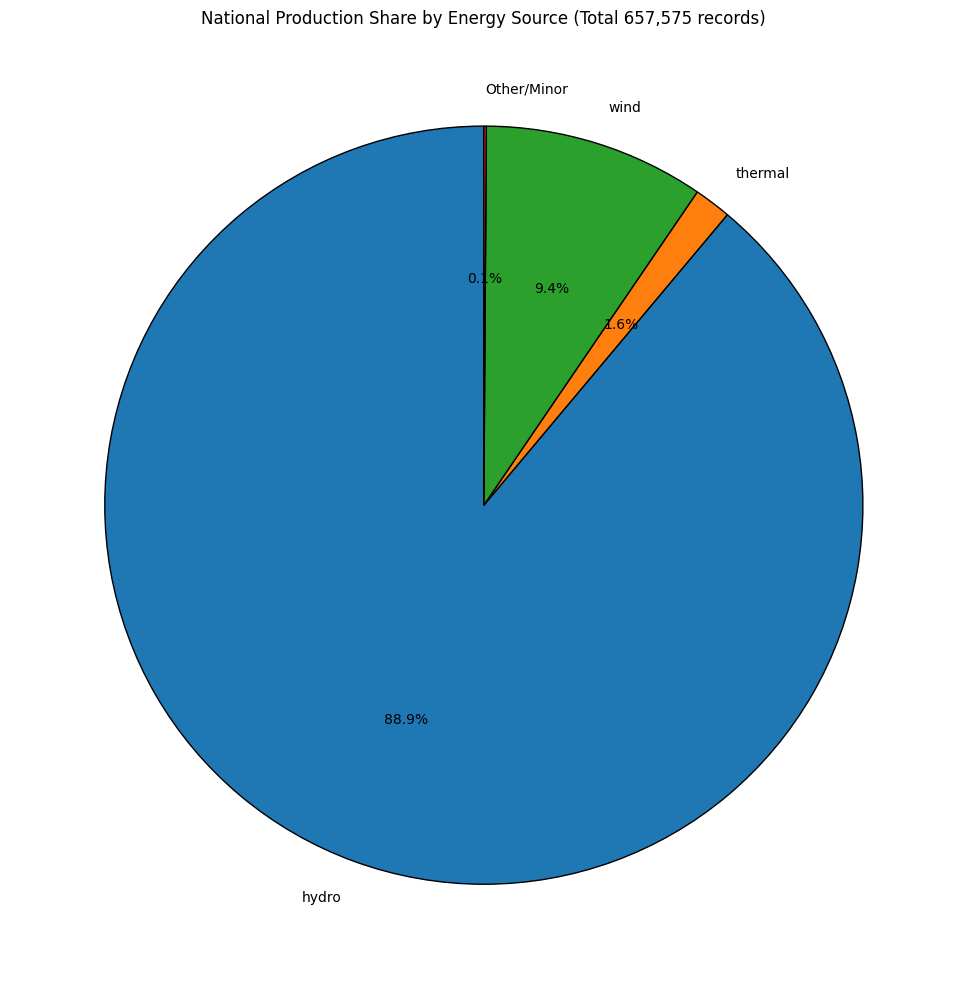

National Pie Chart generated successfully.
Cassandra cluster connection closed.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from cassandra.cluster import Cluster
import time

# --- Cassandra Read-back Audit and Plot (National Pie Chart) ---

# Known row count for full production dataset (2022-2024)
FULL_PRODUCTION_ROW_COUNT = 657575
MAX_ROWS_FOR_PIE = FULL_PRODUCTION_ROW_COUNT # Set limit to total number of rows

# --- Ensure Cassandra Connection is Active ---
print("Ensuring Cassandra connection is active...")
try:
    if 'cassandra_cluster' not in globals() or 'cassandra_cluster' not in locals() or cassandra_cluster.is_shutdown:
        cassandra_cluster = Cluster([CASSANDRA_HOST], port=CASSANDRA_PORT, protocol_version=5)
        cassandra_session = cassandra_cluster.connect()
        cassandra_session.set_keyspace(CASSANDRA_KEYSPACE)
        print("Connection re-established.")
    cassandra_session.set_keyspace(CASSANDRA_KEYSPACE)
except Exception as e:
    print(f"Error during connection re-establishment: {e}")
    
# --- Execute Audit Query for National Pie Chart Data ---

audit_query = f"""
SELECT productiongroup, quantitykwh
FROM {CASSANDRA_KEYSPACE}.{CASSANDRA_PROD_TABLE} 
LIMIT {MAX_ROWS_FOR_PIE}
ALLOW FILTERING
"""

print(f"Executing audit query for National Pie Chart data (Full Count: {MAX_ROWS_FOR_PIE:,} rows)...")

try:
    audit_results = cassandra_session.execute(audit_query)
    audit_df = pd.DataFrame(list(audit_results))
    print(f"Rows read from Cassandra for Pie Chart: {len(audit_df):,}")

except Exception as e:
    print(f"❌ Error fetching data from Cassandra: {e}. Prøv å redusere LIMIT igjen.")
    audit_df = pd.DataFrame() 

# --- Generate Pie Chart ---
if not audit_df.empty:
    # Production aggregation by group
    production_by_group = audit_df.groupby('productiongroup')['quantitykwh'].sum()
    # Filter out very small shares (<0.5%)
    min_threshold = production_by_group.sum() * 0.005
    production_to_plot = production_by_group[production_by_group > min_threshold]
    
    if len(production_by_group) > len(production_to_plot):
         remaining = production_by_group[production_by_group <= min_threshold].sum()
         production_to_plot['Other/Minor'] = remaining

    # --- Plotting ---
    plt.figure(figsize=(10, 10))
    
    plt.pie(
        production_to_plot, 
        labels=production_to_plot.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        wedgeprops={'edgecolor': 'black'}
    )
    
    plt.title(f"National Production Share by Energy Source (Total {len(audit_df):,} records)")
    plt.tight_layout()
    plt.show()
    print("National Pie Chart generated successfully.")
    
else:
    print("No data retrieved for plotting. Cannot generate Pie Chart.")

# Close the Cassandra connection
if 'cassandra_cluster' in locals() and not cassandra_cluster.is_shutdown:
    cassandra_cluster.shutdown()
    print("Cassandra cluster connection closed.")

## MongoDB Bulk Upsert Utility and Production Upsert

In [12]:
# --- MongoDB Bulk Upsert Utility ---

def bulk_upsert_dataframe_to_mongodb(
    data_frame: pd.DataFrame, 
    collection_name: str, 
    key_fields: list[str], 
    batch_size: int = 5000
) -> int:
    """
    Performs a bulk upsert of DataFrame records into a MongoDB collection.
    
    The upsert is based on a compound unique key defined by 'key_fields'.
    """
    # Use certifi for secure connection to MongoDB Atlas
    mongo_client = MongoClient(
        MONGODB_URI, 
        tlsCAFile=certifi.where(), 
        serverSelectionTimeoutMS=30000
    )
    mongo_db = mongo_client[MONGODB_DATABASE_NAME]
    mongo_collection = mongo_db[collection_name]
    
    total_rows = len(data_frame)
    
    # Ensure a unique index exists on the key fields for efficient upserts
    index_name = "unique_composite_key"
    mongo_collection.create_index(
        [(k, 1) for k in key_fields], 
        unique=True, 
        name=index_name
    )
    
    operations, done_count = [], 0
    start_time = time.perf_counter()
    records = data_frame.to_dict('records')
    
    print(f"Starting bulk upsert into {MONGODB_DATABASE_NAME}.{collection_name}...")

    for record in records:
        filter_query = {k: record[k] for k in key_fields}
        update_document = {"$set": record}
        operations.append(UpdateOne(filter_query, update_document, upsert=True))
        
        if len(operations) >= batch_size:
            # Execute the bulk write operation
            try:
                mongo_collection.bulk_write(operations, ordered=False)
            except Exception as e:
                print(f"Error during bulk write at {done_count}: {e}")
            
            done_count += len(operations)
            operations = []
            
            # Print progress update
            elapsed_time = time.perf_counter() - start_time
            rate = done_count / elapsed_time if elapsed_time > 0 else 0
            print(f"Upserted {done_count:,}/{total_rows:,} docs, ~{rate:,.0f}/s")
            
    # Execute the final batch
    if operations:
        try:
            mongo_collection.bulk_write(operations, ordered=False)
        except Exception as e:
            print(f"Error during final bulk write: {e}")
            
        done_count += len(operations)

    end_time = time.perf_counter()
    total_time = end_time - start_time
    final_rate = total_rows / total_time if total_time > 0 else 0
    print(f"MongoDB upsert finished. Total documents upserted: {done_count:,} in {total_time:.2f} seconds ({final_rate:,.0f} docs/s)")
    
    mongo_client.close()
    return done_count

# --- Run Production MongoDB Upsert ---

# Prepare production data for MongoDB
production_data_for_mongo = production_df_2022_2024.copy()
production_data_for_mongo["year"] = production_data_for_mongo["startTime"].dt.year.astype(int)

# MongoDB Key Fields for unique identification (composite primary key)
MONGO_PROD_KEY_FIELDS = ["priceArea", "group", "startTime"]

bulk_upsert_dataframe_to_mongodb(
    production_data_for_mongo, 
    MONGODB_PROD_COLLECTION, 
    MONGO_PROD_KEY_FIELDS
)

Starting bulk upsert into power.production_2022_2024_hourly...
Upserted 5,000/657,575 docs, ~419/s
Upserted 10,000/657,575 docs, ~472/s
Upserted 15,000/657,575 docs, ~462/s
Upserted 20,000/657,575 docs, ~467/s
Upserted 25,000/657,575 docs, ~484/s
Upserted 30,000/657,575 docs, ~496/s
Upserted 35,000/657,575 docs, ~502/s
Upserted 40,000/657,575 docs, ~534/s
Upserted 45,000/657,575 docs, ~537/s
Upserted 50,000/657,575 docs, ~555/s
Upserted 55,000/657,575 docs, ~556/s
Upserted 60,000/657,575 docs, ~558/s
Upserted 65,000/657,575 docs, ~573/s
Upserted 70,000/657,575 docs, ~571/s
Upserted 75,000/657,575 docs, ~570/s
Upserted 80,000/657,575 docs, ~570/s
Upserted 85,000/657,575 docs, ~571/s
Upserted 90,000/657,575 docs, ~569/s
Upserted 95,000/657,575 docs, ~569/s
Upserted 100,000/657,575 docs, ~568/s
Upserted 105,000/657,575 docs, ~568/s
Upserted 110,000/657,575 docs, ~567/s
Upserted 115,000/657,575 docs, ~566/s
Upserted 120,000/657,575 docs, ~570/s
Upserted 125,000/657,575 docs, ~569/s
Upserte

657575

## Consumption Data Fetch, Normalize, and Sanity Check (2021-2024)

In [13]:
# --- Consumption Data Processing (2021 to 2024) ---

CONSUMPTION_START_YEAR = 2021
CONSUMPTION_END_YEAR_INCL = 2024
CONSUMPTION_END_YEAR_EXCL = 2025 # Exclusive end year for filter

print(f"Starting fetch and merge for consumption data ({CONSUMPTION_START_YEAR}-{CONSUMPTION_END_YEAR_INCL})...")

# 1. Fetch and merge all raw JSON data
merged_raw_consumption_data = fetch_and_merge_data_for_year_span(
    CONSUMPTION_START_YEAR, 
    CONSUMPTION_END_YEAR_INCL, 
    DATASET_CONSUMPTION
)

print("Starting data normalization...")
# 2. Normalize the merged JSON data into a clean DataFrame
consumption_df_2021_2024 = normalize_elhub_payload_to_dataframe(
    merged_raw_consumption_data, 
    CONSUMPTION_START_YEAR, 
    CONSUMPTION_END_YEAR_EXCL
)

print(f"\nNormalized consumption rows: {len(consumption_df_2021_2024):,} rows")
print("Price Areas:", sorted(consumption_df_2021_2024.priceArea.unique()))
print("Energy Groups:", sorted(consumption_df_2021_2024["group"].unique()))

# 3. Display Sanity Check and head
run_dataframe_sanity_checks(consumption_df_2021_2024, "Consumption 2021-2024")
consumption_df_2021_2024.head()

Starting fetch and merge for consumption data (2021-2024)...
Fetching CONSUMPTION_PER_GROUP_MBA_HOUR data for: 2021-01...
Fetching CONSUMPTION_PER_GROUP_MBA_HOUR data for: 2021-02...
Fetching CONSUMPTION_PER_GROUP_MBA_HOUR data for: 2021-03...
Fetching CONSUMPTION_PER_GROUP_MBA_HOUR data for: 2021-04...
Fetching CONSUMPTION_PER_GROUP_MBA_HOUR data for: 2021-05...
Fetching CONSUMPTION_PER_GROUP_MBA_HOUR data for: 2021-06...
Fetching CONSUMPTION_PER_GROUP_MBA_HOUR data for: 2021-07...
Fetching CONSUMPTION_PER_GROUP_MBA_HOUR data for: 2021-08...
Fetching CONSUMPTION_PER_GROUP_MBA_HOUR data for: 2021-09...
Fetching CONSUMPTION_PER_GROUP_MBA_HOUR data for: 2021-10...
Monthly fetch failed for 2021-10. Falling back to weekly fetches.
Fetching CONSUMPTION_PER_GROUP_MBA_HOUR data for: 2021-11...
Fetching CONSUMPTION_PER_GROUP_MBA_HOUR data for: 2021-12...
Fetching CONSUMPTION_PER_GROUP_MBA_HOUR data for: 2022-01...
Fetching CONSUMPTION_PER_GROUP_MBA_HOUR data for: 2022-02...
Fetching CONSUMPTIO

year,2021,2022,2023,2024
priceArea,,,,
NO1,43800,43800,43800,43915
NO2,43800,43800,43800,43915
NO3,43800,43800,43800,43915
NO4,43800,43800,43800,43915
NO5,43800,43800,43800,43915


,priceArea,group,startTime,quantityKwh
0,NO1,cabin,2021-01-01 00:00:00+00:00,171335.12
1,NO1,cabin,2021-01-01 01:00:00+00:00,164912.02
2,NO1,cabin,2021-01-01 02:00:00+00:00,160265.77
3,NO1,cabin,2021-01-01 03:00:00+00:00,159828.69
4,NO1,cabin,2021-01-01 04:00:00+00:00,160388.17


## Write Consumption Data to Cassandra and Close Connection

In [26]:
# --- Connect to Cassandra and Prepare Tables for Consumption ---

print("Connecting to Cassandra and preparing consumption table...")
# Connect to the Cassandra cluster
cassandra_cluster = Cluster([CASSANDRA_HOST], port=CASSANDRA_PORT, protocol_version=5)
cassandra_session = cassandra_cluster.connect()
cassandra_session.set_keyspace(CASSANDRA_KEYSPACE)

# Create the consumption table
cassandra_session.execute(f"""
CREATE TABLE IF NOT EXISTS {CASSANDRA_CONS_TABLE} (
  pricearea text,
  consumptiongroup text,
  starttime timestamp,
  quantitykwh double,
  year int,
  PRIMARY KEY ((pricearea, consumptiongroup), starttime)
) WITH CLUSTERING ORDER BY (starttime ASC)
""")


# --- Prepare DataFrame for Cassandra Upsert ---

consumption_data_for_cassandra = consumption_df_2021_2024.copy()

# 1. Compute 'year' column
consumption_data_for_cassandra["year"] = consumption_data_for_cassandra["startTime"].dt.year.astype(int)

# 2. Rename columns to match Cassandra table schema (lowercase)
consumption_data_for_cassandra = consumption_data_for_cassandra.rename(columns={
    "priceArea": "pricearea",
    "group": "consumptiongroup",
    "startTime": "starttime",
    "quantityKwh": "quantitykwh"
})

# Select and order columns
consumption_data_for_cassandra = consumption_data_for_cassandra[
    ["pricearea", "consumptiongroup", "starttime", "quantitykwh", "year"]
]

# 3. Convert timestamps: Remove timezone info
consumption_data_for_cassandra["starttime"] = pd.to_datetime(
    consumption_data_for_cassandra["starttime"], utc=True, errors="coerce"
).dt.tz_localize(None)


# --- Execute Bulk Upsert and Cleanup ---

# Prepare the INSERT statement
consumption_insert_prepared_statement = cassandra_session.prepare(f"""
INSERT INTO {CASSANDRA_CONS_TABLE} (pricearea, consumptiongroup, starttime, quantitykwh, year)
VALUES (?, ?, ?, ?, ?)
""")

# Convert DataFrame rows into a list of argument tuples for concurrent execution
consumption_args = [
    (row.pricearea, row.consumptiongroup, int(row.year),
     row.starttime.to_pydatetime(), 
     float(row.quantitykwh))
    for row in consumption_data_for_cassandra.itertuples(index=False)
]

# Execute concurrent inserts
results = execute_concurrent_with_args(
    cassandra_session, 
    consumption_insert_prepared_statement, 
    consumption_args, 
    concurrency=256, 
    raise_on_first_error=False
)

print(f"Consumption data upsert complete: {len(consumption_args):,} rows written to {CASSANDRA_KEYSPACE}.{CASSANDRA_CONS_TABLE}")

# Close the Cassandra connection
cassandra_cluster.shutdown()
print("Cassandra cluster connection closed.")

Connecting to Cassandra and preparing consumption table...
Consumption data upsert complete: 876,575 rows written to power.consumption_2021_2024
Cassandra cluster connection closed.


## MongoDB Consumption Upsert

In [15]:
# --- Run Consumption MongoDB Upsert ---

# Prepare consumption data for MongoDB
consumption_data_for_mongo = consumption_df_2021_2024.copy()
consumption_data_for_mongo["year"] = consumption_data_for_mongo["startTime"].dt.year.astype(int)

# MongoDB Key Fields for unique identification (composite primary key)
MONGO_CONS_KEY_FIELDS = ["priceArea", "group", "startTime"]

bulk_upsert_dataframe_to_mongodb(
    consumption_data_for_mongo, 
    MONGODB_CONS_COLLECTION, 
    MONGO_CONS_KEY_FIELDS
)

Starting bulk upsert into power.consumption_2021_2024_hourly...
Upserted 5,000/876,575 docs, ~390/s
Upserted 10,000/876,575 docs, ~570/s
Upserted 15,000/876,575 docs, ~563/s
Upserted 20,000/876,575 docs, ~550/s
Upserted 25,000/876,575 docs, ~544/s
Upserted 30,000/876,575 docs, ~540/s
Upserted 35,000/876,575 docs, ~544/s
Upserted 40,000/876,575 docs, ~544/s
Upserted 45,000/876,575 docs, ~544/s
Upserted 50,000/876,575 docs, ~551/s
Upserted 55,000/876,575 docs, ~550/s
Upserted 60,000/876,575 docs, ~548/s
Upserted 65,000/876,575 docs, ~548/s
Upserted 70,000/876,575 docs, ~548/s
Upserted 75,000/876,575 docs, ~550/s
Upserted 80,000/876,575 docs, ~549/s
Upserted 85,000/876,575 docs, ~551/s
Upserted 90,000/876,575 docs, ~553/s
Upserted 95,000/876,575 docs, ~561/s
Upserted 100,000/876,575 docs, ~557/s
Upserted 105,000/876,575 docs, ~557/s
Upserted 110,000/876,575 docs, ~559/s
Upserted 115,000/876,575 docs, ~559/s
Upserted 120,000/876,575 docs, ~559/s
Upserted 125,000/876,575 docs, ~559/s
Upsert

876575

In [17]:
# --- Final MongoDB Validation and Cleanup ---

# Reconnect to MongoDB
mongo_client = MongoClient(
    MONGODB_URI, 
    tlsCAFile=certifi.where(), 
    serverSelectionTimeoutMS=30000
)

database = mongo_client[MONGODB_DATABASE_NAME]

# Collections for production and consumption
production_collection = database[MONGODB_PROD_COLLECTION]
consumption_collection = database[MONGODB_CONS_COLLECTION]

print("--- MongoDB Collection Counts and Areas ---")
print(f"Production Collection ({MONGODB_PROD_COLLECTION}) Count: {production_collection.count_documents({}):,}")
print(f"Consumption Collection ({MONGODB_CONS_COLLECTION}) Count: {consumption_collection.count_documents({}):,}")
print("-" * 45)

# Validate distinct price areas and groups in production
print("Production Areas:", sorted(production_collection.distinct("priceArea")))
print("Production Groups:", sorted(production_collection.distinct("group"))[:10])

# Validate distinct price areas and groups in consumption
print("Consumption Areas:", sorted(consumption_collection.distinct("priceArea")))
print("Consumption Groups:", sorted(consumption_collection.distinct("group"))[:10])

# Close the MongoDB connection
mongo_client.close()
print("\nMongoDB connection closed. Validation complete. \n YOU THE GOAT!  🐐")

--- MongoDB Collection Counts and Areas ---
Production Collection (production_2022_2024_hourly) Count: 657,575
Consumption Collection (consumption_2021_2024_hourly) Count: 876,575
---------------------------------------------
Production Areas: ['NO1', 'NO2', 'NO3', 'NO4', 'NO5']
Production Groups: ['hydro', 'other', 'solar', 'thermal', 'wind']
Consumption Areas: ['NO1', 'NO2', 'NO3', 'NO4', 'NO5']
Consumption Groups: ['cabin', 'household', 'primary', 'secondary', 'tertiary']

MongoDB connection closed. Validation complete. 
 YOU THE GOAT!  🐐


# Streamlit Application

So I implemented 4 new sites, Map, Snow Drift, Weather Energy Corralation and llastly Energy Forecasting(SARIMAX).

### Map
This is the most timeconsuming one, after what felt like three days, it finaly worked. So I used GeoJSON caching using the st.cache_data function to effiently load and reuse the data for the price area (NO1-NO5), reducing initial load time. Developed a ontrol panel for choosing the data source, group and time interval to compute mean kWh and Mean GWh for producion-group (example Hydro) to simplify the numbers. I used Folium to create a choropleth map of the price area and highlighting the selected region. Lastly enabled map click functionality and sotred the selevted coordinate in st.session_state["map_coord"] for subsequent use on the snow drift page.

### Snow Drift
Like I just said I reused the coordinates in ["map_coord"] as the primary input location for meteorolgical data fetching. 
Then downloaded hourly meteorological data from the Open-Meteo archive. Changed the required seasonal periods (July - June ). 

Utilized ezisting functions in utils.Snow_drift to compute the yearly snow transport potential ($Q_t$)  for each season and the average directional sector. 

### Bonus Content
For the bonus content, I think I have added a "waiting time - spinner" using st.spinner() and try/except blocks around heavy computations for user feedback. Also cached everything using st.cache_data on load_elhub_production_data and load_elhub_consumption_data. 



